In [3]:
import numpy as np
import torch

import sys, os

sys.path.append("../")

from vi_rnn.saving import load_model
import matplotlib.pyplot as plt
from vi_rnn.generate import generate

%matplotlib inline

# We used openly accessible electroencephalogram (EEG) data from Schalk et al. 2004
# available from https://www.physionet.org/content/eegmmidb/1.0.0/ (Moody et al. 2000; ODC-BY licence).
# This repo includes preprocessed data from session S001R01.

In [4]:
# Load model
name = "EEG_Inv_Obs_LRRNN_Z_Date_32024_07_29_T_17_43_46"
vae, training_params, task_params = load_model(
    "../models/sweep_eeg_rs/" + name, load_encoder=False, backward_compat=True
)



# retrained model by RBM
# my hosted model on 2 min rest plus task
name = "rbm_forenzo_EEG_low_rank_affine_dim_z_3_date_2026_03_29_T_19_56_20"
vae, training_params, task_params = load_model(
    "../models/sweep_eeg/" + name, load_encoder=False, backward_compat=True
)


# Load data
raw_dat = np.load("Forenzo2023_subject_1_zscored.npy")
smooth_dat = np.load("Forenzo2023_subject_1_zscored_smoothed.npy")

using uniform init
key transition.hz not found in rnn, deleted
no out nonlinearity found, setting to identity
using uniform init
Initialising VAE without encoder


In [5]:
from evaluation.pse import power_spectrum_helling as pse
from evaluation.kl_Gauss import calc_kl_from_data

In [6]:
# Generate data

t1 = 1200
# generate data using our fit model
Z, _, data_gen, rates_gen = generate(
    vae,
    u=None,
    x=torch.from_numpy(raw_dat[t1:].T.astype(np.float32)),
    initial_state="posterior_mean",
    k=1,
    dur=800,
)

In [7]:
# channel names (extracted from the Physionet data using MNE (https://mne.tools/stable/index.htmlZ))

channels = [
    "Fc5.",
    "Fc3.",
    "Fc1.",
    "Fcz.",
    "Fc2.",
    "Fc4.",
    "Fc6.",
    "C5..",
    "C3..",
    "C1..",
    "Cz..",
    "C2..",
    "C4..",
    "C6..",
    "Cp5.",
    "Cp3.",
    "Cp1.",
    "Cpz.",
    "Cp2.",
    "Cp4.",
    "Cp6.",
    "Fp1.",
    "Fpz.",
    "Fp2.",
    "Af7.",
    "Af3.",
    "Afz.",
    "Af4.",
    "Af8.",
    "F7..",
    "F5..",
    "F3..",
    "F1..",
    "Fz..",
    "F2..",
    "F4..",
    "F6..",
    "F8..",
    "Ft7.",
    "Ft8.",
    "T7..",
    "T8..",
    "T9..",
    "T10.",
    "Tp7.",
    "Tp8.",
    "P7..",
    "P5..",
    "P3..",
    "P1..",
    "Pz..",
    "P2..",
    "P4..",
    "P6..",
    "P8..",
    "Po7.",
    "Po3.",
    "Poz.",
    "Po4.",
    "Po8.",
    "O1..",
    "Oz..",
    "O2..",
    "Iz..",
]

/var/folders/qz/p18pr5ys7pv1_vbn3jwdb4b00000gn/T/ipykernel_93234/2037136509.py:4: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4483.)
  axs[1].plot(data_gen[0, ch_n, :, 0].T + i * 4, lw=1, color="slategrey")


Text(0, 0.5, 'channel name')

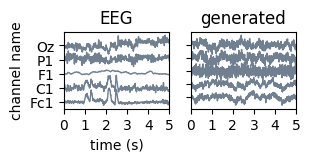

In [8]:
plt_chs = [2, 9, 32, 49, 61]
fig, axs = plt.subplots(1, 2, figsize=(3, 1))
for i, ch_n in enumerate(plt_chs):
    axs[1].plot(data_gen[0, ch_n, :, 0].T + i * 4, lw=1, color="slategrey")

t1 = 1500
for i, ch_n in enumerate(plt_chs):
    axs[0].plot(raw_dat[t1 : 800 + t1, ch_n].T + i * 4, lw=1, color="slategrey")

axs[0].set_xlim(0, 800)
axs[1].set_xlim(0, 800)
axs[0].set_yticks(range(0, 20, 4))
axs[1].set_yticks(range(0, 20, 4))
axs[0].set_yticklabels([channels[ch_n].strip(".") for ch_n in plt_chs])
axs[1].set_yticklabels([])
axs[0].set_xticks(np.arange(0, 160 * 5 + 1, 160))
axs[0].set_xticklabels(np.arange(0, 1 * 5 + 1, 1))
axs[1].set_yticklabels([])
axs[1].set_xticks(np.arange(0, 160 * 5 + 1, 160))
axs[1].set_xticklabels(np.arange(0, 1 * 5 + 1, 1))
axs[0].set_xlabel("time (s)")
axs[0].set_title("EEG")
axs[1].set_title("generated")
axs[0].set_ylabel("channel name")

# plt.savefig("../figures/fig_EEG.pdf", bbox_inches="tight")

In [9]:
# Generate more data

with torch.no_grad():
    # generate data using our fit model
    Z, _, data_gen, rates_gen = generate(
        vae,
        u=None,
        x=torch.from_numpy(raw_dat.T.astype(np.float32)),
        initial_state="posterior_mean",
        k=1,
    )

Text(0.5, 1.0, 'EEG')

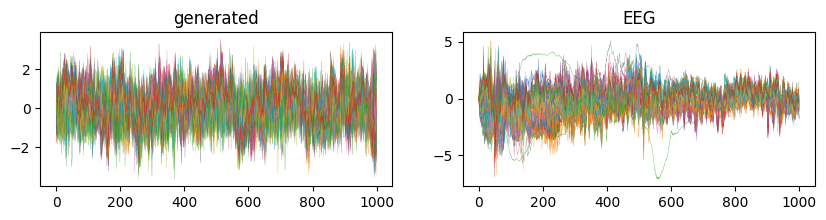

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 2))

t = 1000
ax[0].plot(data_gen[0, :, :t, 0].T, lw=0.2, alpha=1)
ax[1].plot(raw_dat[:t], lw=0.2, alpha=1)
ax[0].set_title("generated")
ax[1].set_title("EEG")

Text(0.5, 1.0, 'EEG')

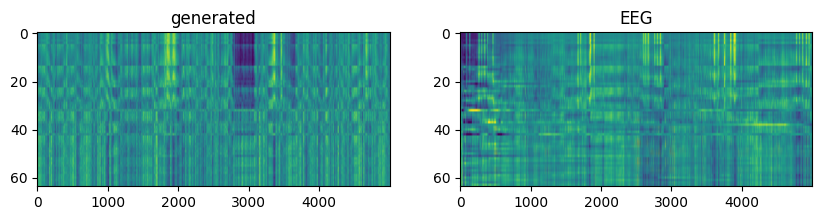

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 2))
vlim = 4
t = 5000
ax[0].imshow(
    data_gen[0, :, :t, 0], aspect="auto", cmap="viridis", vmin=-vlim, vmax=vlim
)
ax[1].imshow(raw_dat.T[:, :t], cmap="viridis", aspect="auto", vmin=-vlim, vmax=vlim)
ax[0].set_title("generated")
ax[1].set_title("EEG")

In [12]:
"""save generated data to numpy"""
data_gen_np = (
    data_gen.squeeze()        # -> (64, 9760)
     .permute(1, 0)    # -> (9760, 64)
     .cpu()            # if on GPU
     .numpy()
)

np.save("../rbm_stuff/rnn_generated_data.npy", data_gen_np)
np.save("../rbm_stuff/real_data.npy", raw_dat)


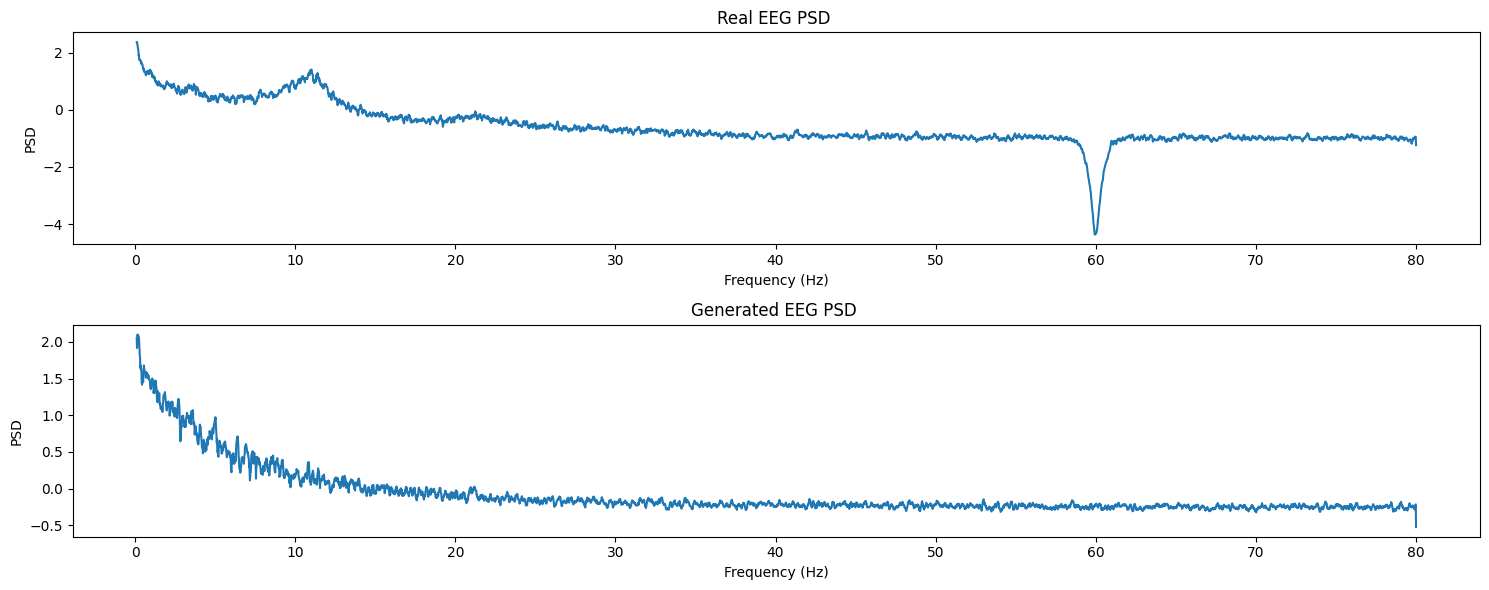

In [13]:
import matplotlib.pyplot as plt
import mne
import numpy as np

trial_idx = 2
sfreq = 160

plt.figure(figsize=(15, 6))

# --- REAL ---
plt.subplot(2, 1, 1)
plt.title(f"Real EEG PSD ")

psd_real, freqs = mne.time_frequency.psd_array_multitaper(
    raw_dat.T, sfreq=sfreq, fmin=0.1, fmax=80, verbose=False
)

plt.plot(freqs, np.log10(psd_real.mean(axis=0)))  # average over channels
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")

# --- GENERATED ---
plt.subplot(2, 1, 2)
plt.title(f"Generated EEG PSD ")

psd_gen, freqs = mne.time_frequency.psd_array_multitaper(
    data_gen[0, :, :, 0], sfreq=sfreq, fmin=0.1, fmax=80, verbose=False
)

plt.plot(freqs, np.log10(psd_gen.mean(axis=0)))
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")

plt.tight_layout()
plt.show()

/var/folders/qz/p18pr5ys7pv1_vbn3jwdb4b00000gn/T/ipykernel_93234/2092139044.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  gen_dat = np.array(data_gen[0, :, :, 0].T)


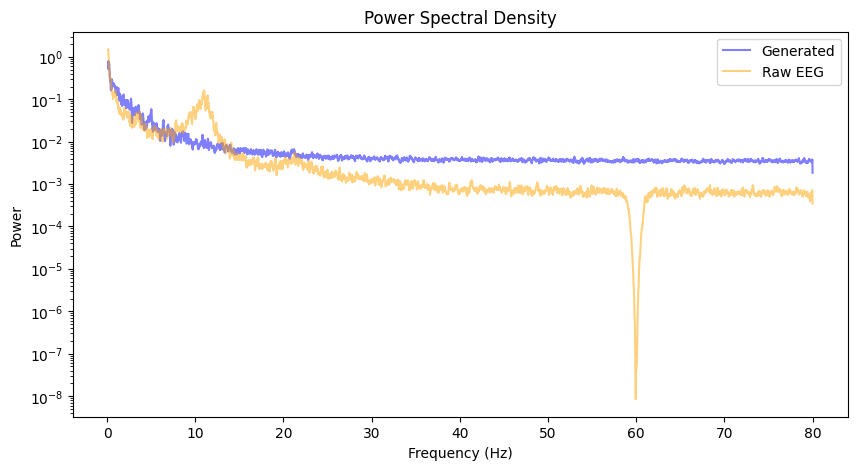

In [14]:
from mne.time_frequency import psd_array_multitaper
fs = 160  # sampling frequency

# plot Power spectrums of raw_dat and gen_dat 
gen_dat = np.array(data_gen[0, :, :, 0].T)
psd_gen, freqs_gen = psd_array_multitaper(gen_dat.T, sfreq=fs, fmin=0.1, fmax=80, adaptive=True, normalization='full', verbose=0)
psd_raw, freqs_raw = psd_array_multitaper(raw_dat.T, sfreq=fs, fmin=0.1, fmax=80, adaptive=True, normalization='full', verbose=0)
plt.figure(figsize=(10, 5))
plt.semilogy(freqs_gen, np.mean(psd_gen.T, axis=1), color='blue', alpha=0.5, label='Generated')
plt.semilogy(freqs_raw, np.mean(psd_raw.T, axis=1), color='orange', alpha=0.5, label='Raw EEG')
plt.title("Power Spectral Density")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.legend()
plt.show()
